
 ERA5MultiData Test Suite
Test 1: Load Full Dataset
Loading ERA5 data from C:\Users\micke\Downloads\dfda178b22d3772b9b9b0118dba68a02.nc
No slicing applied - using all indices
Coordinate ranges:
  valid_time: shape=(24,), range=[1664323200.00, 1664406016.00]
  pressure_level: shape=(17,), range=[200.00, 850.00]
  latitude: shape=(721,), range=[-90.00, 90.00]
  longitude: shape=(1440,), range=[-180.00, 179.75]
Preloading data into memory...
  Loading u...
    Memory usage: 1.69 GB
  Loading v...
    Memory usage: 1.69 GB
  Loading w...
    Memory usage: 1.69 GB
  Loading z...
    Memory usage: 1.69 GB
Successfully loaded 4 variables:
   u: (24, 17, 721, 1440)
   v: (24, 17, 721, 1440)
   w: (24, 17, 721, 1440)
   z: (24, 17, 721, 1440)

✅ Dataset loaded successfully!
  Input dimensions: 4
  Output dimensions: 4
  Coordinate order: ['valid_time', 'pressure_level', 'latitude', 'longitude']
  Variable order: ['u', 'v', 'w', 'z']

  Shape information:
    Times: 24
    Pressure levels: 17
 

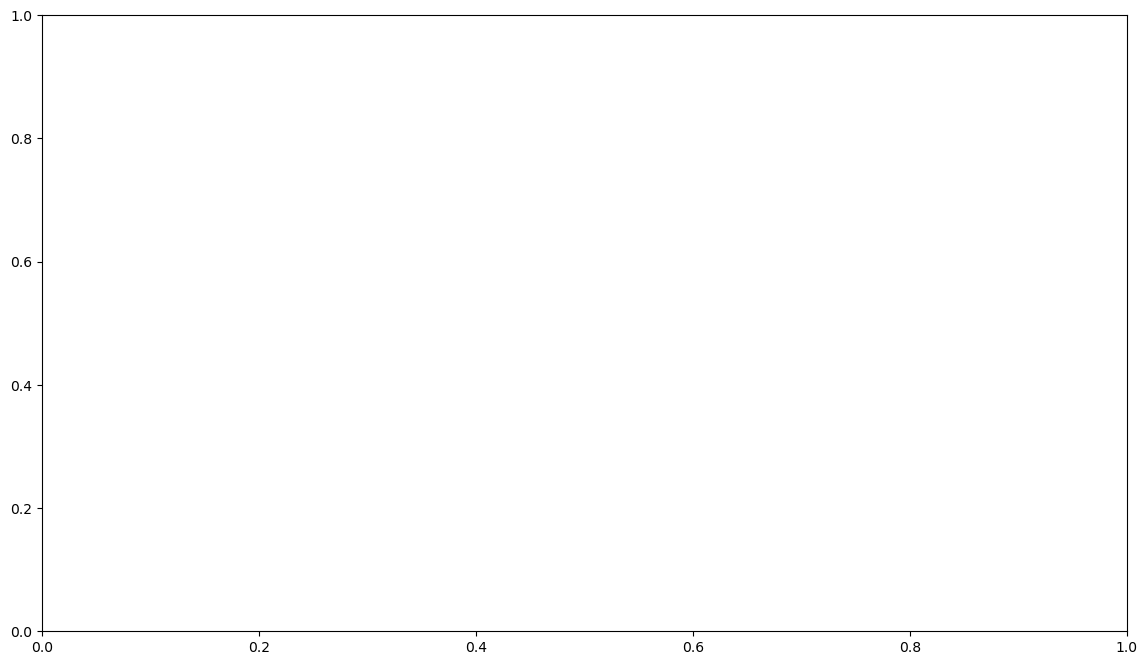

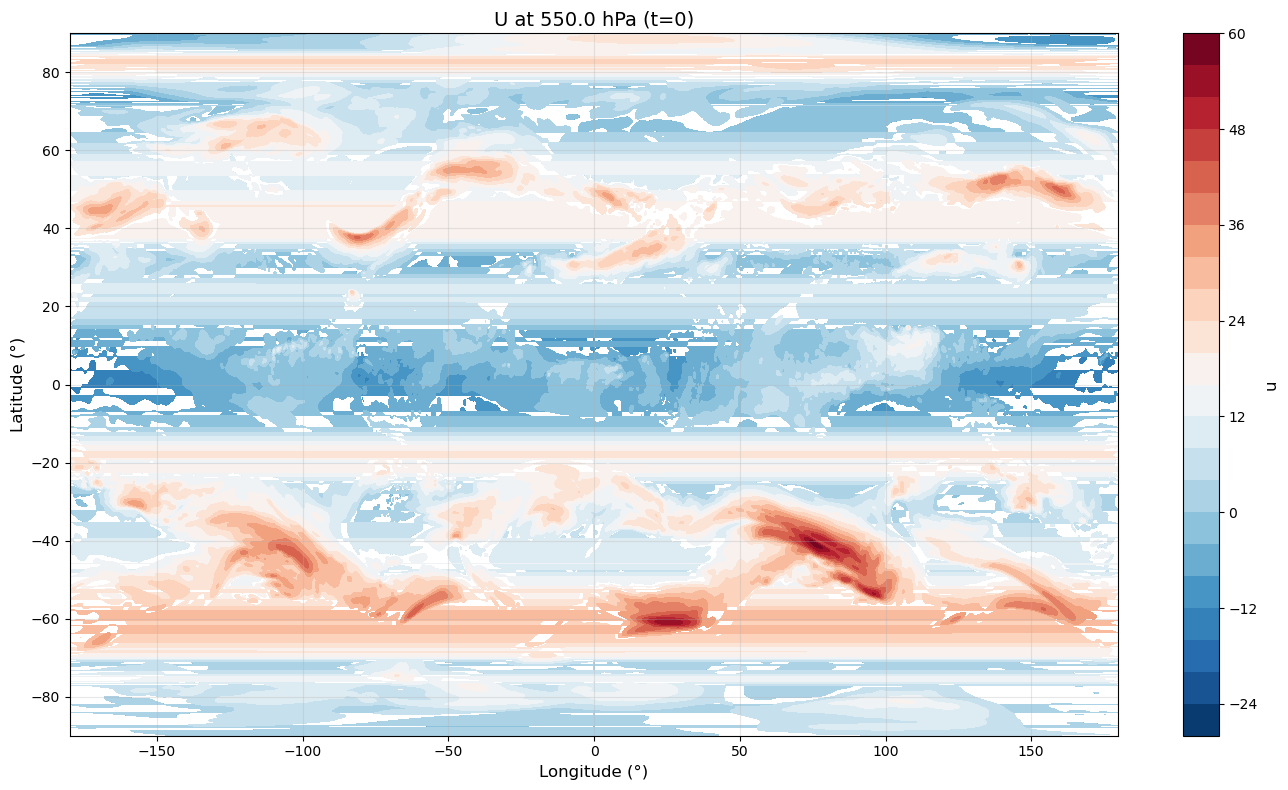


✅ Horizontal slice visualized!

Test 6: Visualize Vertical Cross-Section

  Plotting u meridional section at:
    Time index: 0
    Longitude: -180.0°
    Slice shape: (17, 721) (pressure × latitude)


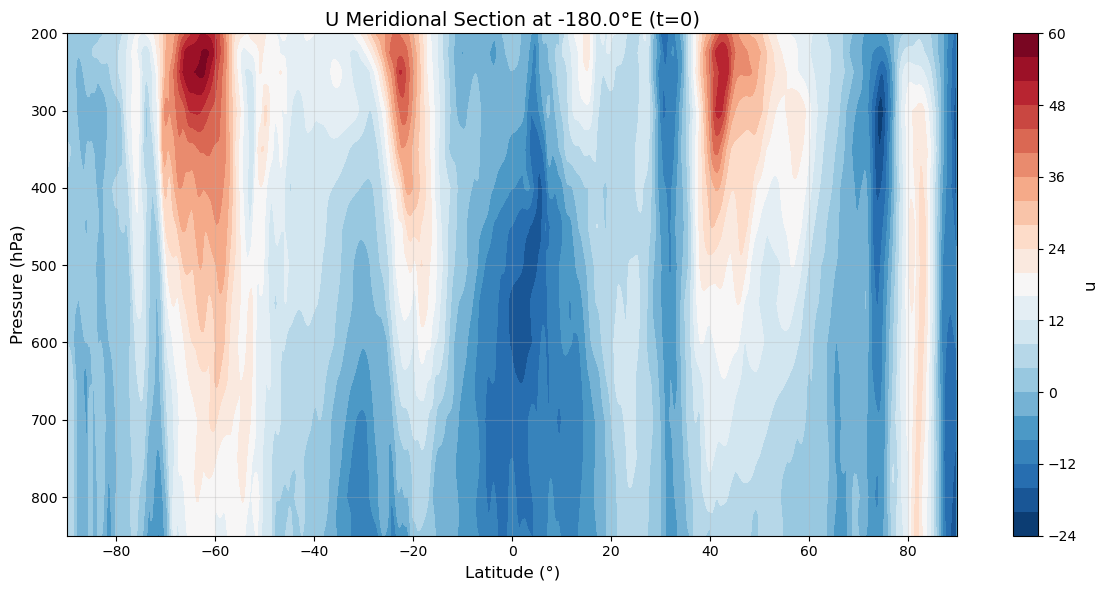


✅ Vertical cross-section visualized!

Test 7: Visualize Time Series

  Plotting u time series at:
    Pressure: 850.0 hPa
    Latitude: 0.0°
    Longitude: -180.0°
    Series length: 24


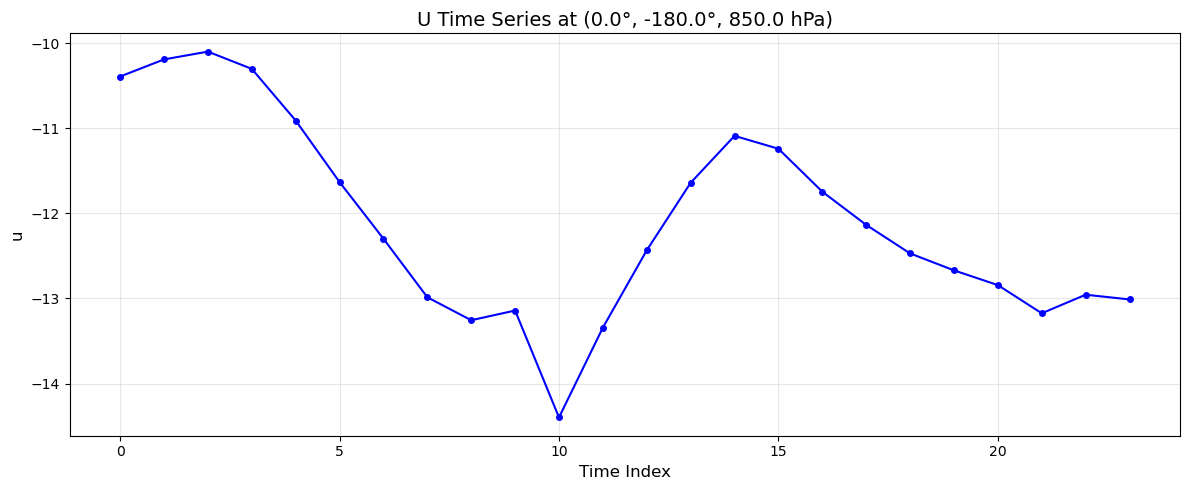


✅ Time series visualized!

Test 8: Compare All Variables


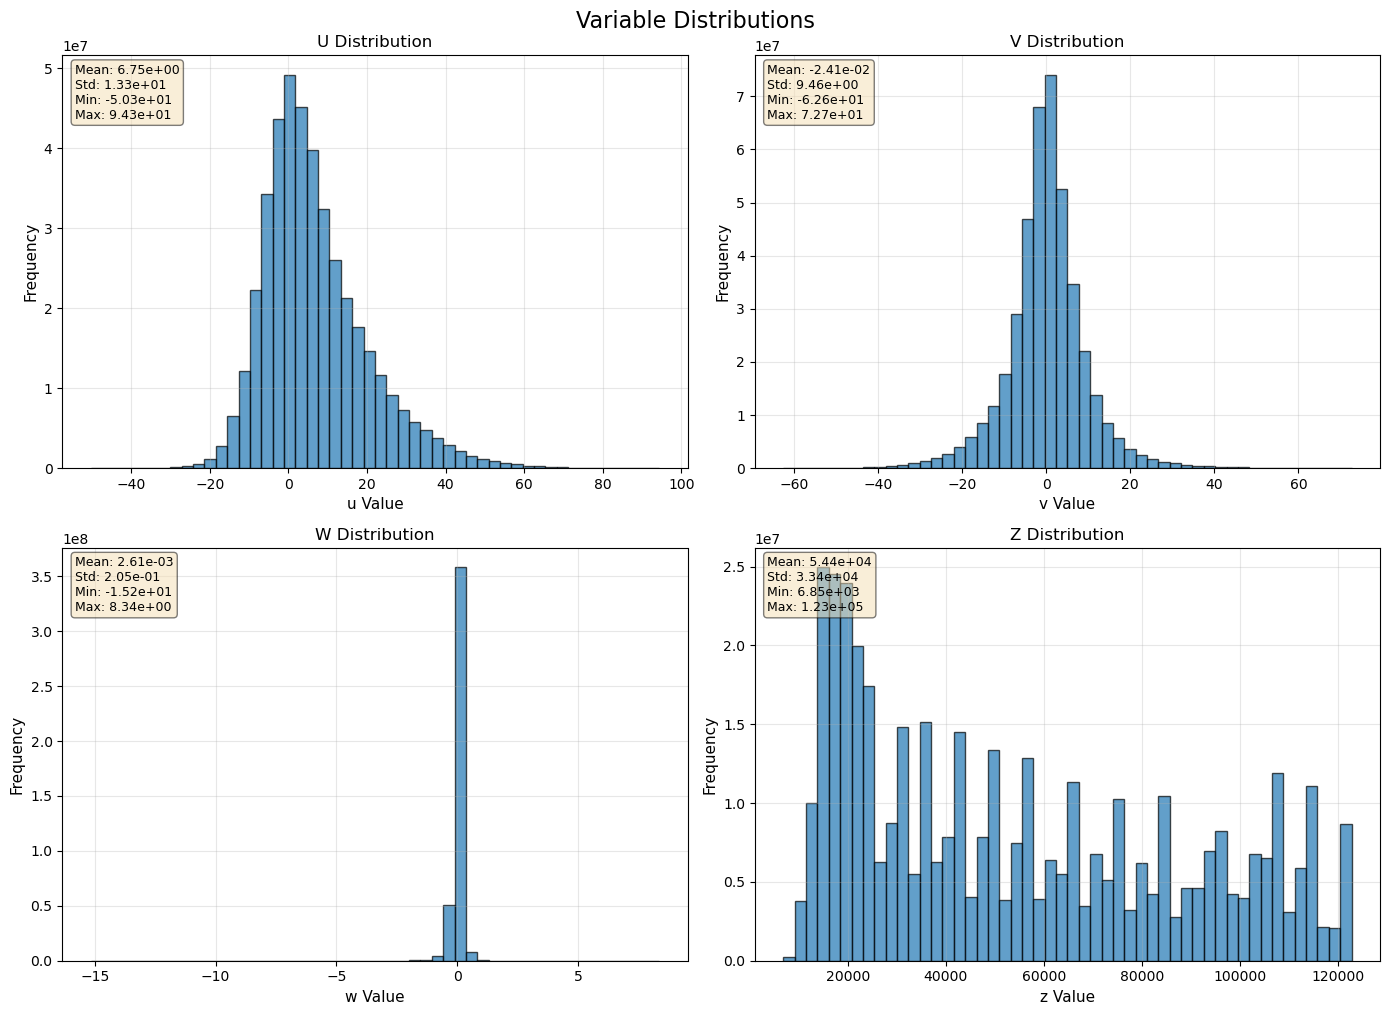


✅ Variable comparison complete!

Test 9: Coordinate Labels and Ordering

  Coordinate labels (name → index):
    valid_time: 0
    pressure_level: 1
    latitude: 2
    longitude: 3

  Coordinate order: ['valid_time', 'pressure_level', 'latitude', 'longitude']

  Variable labels (name → index):
    u: 0
    v: 1
    w: 2
    z: 3

  Variable order: ['u', 'v', 'w', 'z']

✅ Coordinate and variable ordering verified!

Test 10: 3D Scatter of Data Points

  Sampled 1000 random points
  Coordinates shape: (1000, 4)
  Values shape: (1000,)


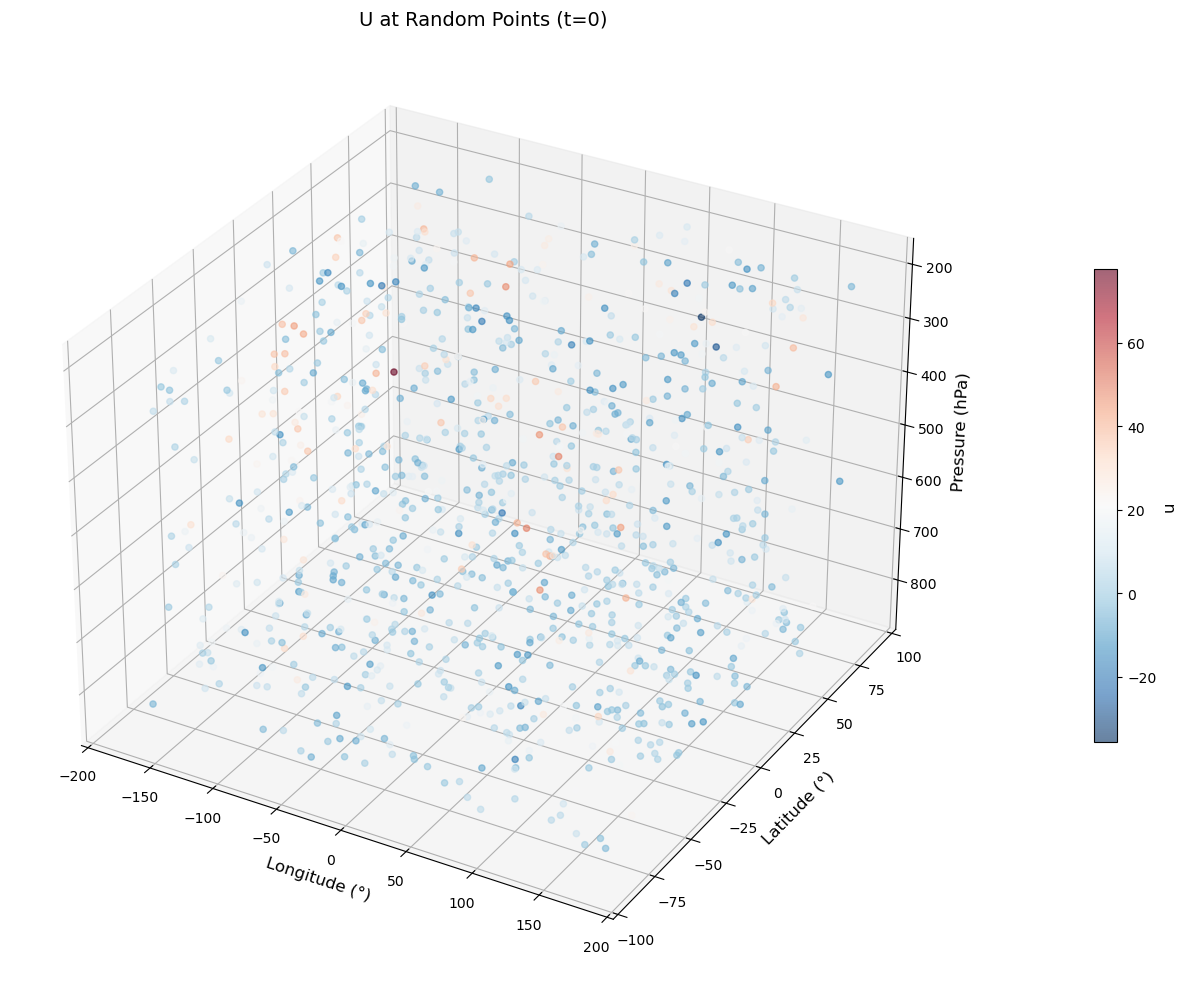


✅ 3D scatter plot created!

 ✅ All Tests Completed Successfully!


In [3]:
# Test Notebook for ERA5MultiData

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

import sys
sys.path.insert(0, r'C:\Users\micke\OneDrive - University of Toronto\geo_lab')
from geolab.data.dataset import ERA5MultiData

# ============================================================================
# CONFIGURATION - UPDATE THESE PATHS
# ============================================================================
DATA_DIR = Path(r"C:\Users\micke\Downloads\dfda178b22d3772b9b9b0118dba68a02.nc")
VARIABLES = ['u', 'v', 'w', 'z']

# ============================================================================
# Test 1: Load Full Dataset
# ============================================================================
def test_load_full_dataset():
    """Test loading the complete dataset."""
    print("=" * 60)
    print("Test 1: Load Full Dataset")
    print("=" * 60)

    data = ERA5MultiData(
        data_dir=DATA_DIR,
        variables=VARIABLES,
        preload=True
    )

    print(f"\n Dataset loaded successfully!")
    print(f"  Input dimensions: {data.input_dim}")
    print(f"  Output dimensions: {data.output_dim}")
    print(f"  Coordinate order: {data.coord_order}")
    print(f"  Variable order: {data.var_order}")
    print(f"\n  Shape information:")
    print(f"    Times: {data.num_times}")
    print(f"    Pressure levels: {data.num_pressure_levels}")
    print(f"    Latitudes: {data.num_latitudes}")
    print(f"    Longitudes: {data.num_longitudes}")
    print(f"    Total grid points: {data.num_times * data.num_pressure_levels * data.num_latitudes * data.num_longitudes:,}")

    return data


# ============================================================================
# Test 2: Load with Slicing
# ============================================================================
def test_load_with_slicing():
    """Test loading with spatial and temporal slicing."""
    print("\n" + "=" * 60)
    print("Test 2: Load with Slicing")
    print("=" * 60)

    data_sliced = ERA5MultiData(
        data_dir=DATA_DIR,
        variables=VARIABLES,
        time_idx_range=[0, 10],           # First 10 time steps
        pressure_idx_range=[0, 5],        # First 5 pressure levels
        latitude_idx_range=[0, 50],       # First 50 latitudes
        longitude_idx_range=[0, 100],     # First 100 longitudes
        preload=True
    )

    print(f"\n Sliced dataset loaded!")
    print(f"  Shape information:")
    print(f"    Times: {data_sliced.num_times}")
    print(f"    Pressure levels: {data_sliced.num_pressure_levels}")
    print(f"    Latitudes: {data_sliced.num_latitudes}")
    print(f"    Longitudes: {data_sliced.num_longitudes}")

    return data_sliced


# ============================================================================
# Test 3: Test Coordinate Access
# ============================================================================
def test_coordinate_access(data):
    """Test accessing coordinate values."""
    print("\n" + "=" * 60)
    print("Test 3: Coordinate Access")
    print("=" * 60)

    # Get coordinate arrays
    lons = data.longitudes
    lats = data.latitudes
    press = data.pressure_levels
    times = data.times

    print(f"\n Coordinate arrays retrieved!")
    print(f"  Longitude range: [{lons.min():.2f}, {lons.max():.2f}]°")
    print(f"  Latitude range: [{lats.min():.2f}, {lats.max():.2f}]°")
    print(f"  Pressure range: [{press.min():.2f}, {press.max():.2f}] hPa")
    print(f"  Time range: [{times.min():.2e}, {times.max():.2e}] seconds since epoch")

    # Test get_coords_at_index
    coords_at_point = data.get_coords_at_index(
        time_idx=0,
        pressure_idx=0,
        latitude_idx=0,
        longitude_idx=0
    )

    print(f"\n  Coordinates at origin index:")
    print(f"    Time: {coords_at_point[0]:.2e}")
    print(f"    Pressure: {coords_at_point[1]:.2f} hPa")
    print(f"    Latitude: {coords_at_point[2]:.2f}°")
    print(f"    Longitude: {coords_at_point[3]:.2f}°")


# ============================================================================
# Test 4: Test Variable Access
# ============================================================================
def test_variable_access(data):
    """Test accessing variable data."""
    print("\n" + "=" * 60)
    print("Test 4: Variable Access")
    print("=" * 60)

    # Get first variable
    var_name = VARIABLES[0]
    var_data = data.get_variable(var_name)

    print(f"\n Variable '{var_name}' retrieved!")
    print(f"  Shape: {var_data.shape}")
    print(f"  Data type: {var_data.dtype}")
    print(f"  Value range: [{var_data.min():.4f}, {var_data.max():.4f}]")
    print(f"  Mean: {var_data.mean():.4f}")
    print(f"  Std: {var_data.std():.4f}")

    # Test get_values_at_index
    value_at_point = data.get_values_at_index(
        var_name=var_name,
        time_idx=0,
        pressure_idx=0,
        latitude_idx=data.num_latitudes // 2,  # Mid-latitude
        longitude_idx=0
    )

    print(f"\n  {var_name} at (t=0, p=0, lat=mid, lon=0): {value_at_point:.4f}")

    return var_data


# ============================================================================
# Test 5: Visualize Horizontal Slice
# ============================================================================
def test_visualize_horizontal_slice(data):
    """Visualize a horizontal slice at a fixed pressure level."""
    print("\n" + "=" * 60)
    print("Test 5: Visualize Horizontal Slice")
    print("=" * 60)

    var_name = VARIABLES[0]
    time_idx = 0
    pressure_idx = data.num_pressure_levels // 2  # Mid-level

    # Get 2D slice
    var_slice = data.data_arrays[var_name][time_idx, pressure_idx, :, :]

    print(f"\n  Plotting {var_name} at:")
    print(f"    Time index: {time_idx}")
    print(f"    Pressure: {data.pressure_levels[pressure_idx]:.1f} hPa")
    print(f"    Slice shape: {var_slice.shape}")

    # Create meshgrid
    lat_grid, lon_grid = np.meshgrid(data.latitudes, data.longitudes, indexing='ij')

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))

    im = ax.contourf(lon_grid, lat_grid, var_slice, levels=20, cmap='RdBu_r')
    ax.set_xlabel('Longitude (°)', fontsize=12)
    ax.set_ylabel('Latitude (°)', fontsize=12)
    ax.set_title(f'{var_name.upper()} at {data.pressure_levels[pressure_idx]:.1f} hPa (t={time_idx})',
                 fontsize=14)
    ax.grid(True, alpha=0.3)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f'{var_name}', fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"\n Horizontal slice visualized!")


# ============================================================================
# Test 6: Visualize Vertical Cross-Section
# ============================================================================
def test_visualize_vertical_section(data):
    """Visualize a meridional cross-section."""
    print("\n" + "=" * 60)
    print("Test 6: Visualize Vertical Cross-Section")
    print("=" * 60)

    var_name = VARIABLES[0]
    time_idx = 0
    lon_idx = data.num_longitudes // 2  # Mid-longitude

    # Get lat-pressure slice
    var_slice = data.data_arrays[var_name][time_idx, :, :, lon_idx]

    print(f"\n  Plotting {var_name} meridional section at:")
    print(f"    Time index: {time_idx}")
    print(f"    Longitude: {data.longitudes[lon_idx]:.1f}°")
    print(f"    Slice shape: {var_slice.shape} (pressure × latitude)")

    # Create meshgrid
    lat_grid, pressure_grid = np.meshgrid(data.latitudes, data.pressure_levels, indexing='ij')

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    # Transpose for proper orientation
    im = ax.contourf(lat_grid.T, pressure_grid.T, var_slice, levels=20, cmap='RdBu_r')
    ax.invert_yaxis()  # Pressure increases downward
    ax.set_xlabel('Latitude (°)', fontsize=12)
    ax.set_ylabel('Pressure (hPa)', fontsize=12)
    ax.set_title(f'{var_name.upper()} Meridional Section at {data.longitudes[lon_idx]:.1f}°E (t={time_idx})',
                 fontsize=14)
    ax.grid(True, alpha=0.3)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f'{var_name}', fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"\n Vertical cross-section visualized!")


# ============================================================================
# Test 7: Visualize Time Series
# ============================================================================
def test_visualize_time_series(data):
    """Visualize time series at a fixed location."""
    print("\n" + "=" * 60)
    print("Test 7: Visualize Time Series")
    print("=" * 60)

    var_name = VARIABLES[0]
    pressure_idx = 0  # Upper level
    lat_idx = data.num_latitudes // 2
    lon_idx = data.num_longitudes // 2

    # Extract time series
    time_series = data.data_arrays[var_name][:, pressure_idx, lat_idx, lon_idx]

    print(f"\n  Plotting {var_name} time series at:")
    print(f"    Pressure: {data.pressure_levels[pressure_idx]:.1f} hPa")
    print(f"    Latitude: {data.latitudes[lat_idx]:.1f}°")
    print(f"    Longitude: {data.longitudes[lon_idx]:.1f}°")
    print(f"    Series length: {len(time_series)}")

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))

    ax.plot(range(len(time_series)), time_series, 'b-o', markersize=4)
    ax.set_xlabel('Time Index', fontsize=12)
    ax.set_ylabel(f'{var_name}', fontsize=12)
    ax.set_title(f'{var_name.upper()} Time Series at ({data.latitudes[lat_idx]:.1f}°, {data.longitudes[lon_idx]:.1f}°, {data.pressure_levels[pressure_idx]:.1f} hPa)',
                 fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n Time series visualized!")


# ============================================================================
# Test 8: Compare All Variables
# ============================================================================
def test_compare_variables(data):
    """Compare statistics of all variables."""
    print("\n" + "=" * 60)
    print("Test 8: Compare All Variables")
    print("=" * 60)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, var_name in enumerate(VARIABLES[:4]):  # First 4 variables
        var_data = data.data_arrays[var_name]

        # Flatten for histogram
        var_flat = var_data.flatten()

        # Plot histogram
        axes[idx].hist(var_flat, bins=50, alpha=0.7, edgecolor='black')
        axes[idx].set_xlabel(f'{var_name} Value', fontsize=11)
        axes[idx].set_ylabel('Frequency', fontsize=11)
        axes[idx].set_title(f'{var_name.upper()} Distribution', fontsize=12)
        axes[idx].grid(True, alpha=0.3)

        # Add statistics
        stats_text = f'Mean: {var_flat.mean():.2e}\nStd: {var_flat.std():.2e}\nMin: {var_flat.min():.2e}\nMax: {var_flat.max():.2e}'
        axes[idx].text(0.02, 0.98, stats_text,
                      transform=axes[idx].transAxes,
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                      fontsize=9)

    plt.tight_layout()
    plt.suptitle('Variable Distributions', y=1.01, fontsize=16)
    plt.show()

    print(f"\n Variable comparison complete!")


# ============================================================================
# Test 9: Test Coordinate Labels and Ordering
# ============================================================================
def test_coordinate_labels(data):
    """Test coordinate labels and ordering."""
    print("\n" + "=" * 60)
    print("Test 9: Coordinate Labels and Ordering")
    print("=" * 60)

    print(f"\n  Coordinate labels (name → index):")
    for name, idx in sorted(data.coord_labels.items(), key=lambda x: x[1]):
        print(f"    {name}: {idx}")

    print(f"\n  Coordinate order: {data.coord_order}")

    print(f"\n  Variable labels (name → index):")
    for name, idx in sorted(data.variable_labels.items(), key=lambda x: x[1]):
        print(f"    {name}: {idx}")

    print(f"\n  Variable order: {data.var_order}")

    # Verify ordering matches labels
    coord_order_check = sorted(data.coord_labels.keys(),
                               key=lambda k: data.coord_labels[k])
    var_order_check = sorted(data.variable_labels.keys(),
                            key=lambda k: data.variable_labels[k])

    assert data.coord_order == coord_order_check, "Coord order mismatch!"
    assert data.var_order == var_order_check, "Var order mismatch!"

    print(f"\n Coordinate and variable ordering verified!")


# ============================================================================
# Test 10: 3D Scatter of Data Points
# ============================================================================
def test_3d_scatter(data):
    """Create 3D scatter plot of random data points."""
    print("\n" + "=" * 60)
    print("Test 10: 3D Scatter of Data Points")
    print("=" * 60)

    # Sample random points
    n_samples = 1000
    time_idx = 0

    np.random.seed(42)
    pressure_samples = np.random.randint(0, data.num_pressure_levels, n_samples)
    lat_samples = np.random.randint(0, data.num_latitudes, n_samples)
    lon_samples = np.random.randint(0, data.num_longitudes, n_samples)

    # Get coordinates
    coords = data.get_coords_at_index(
        time_idx=np.full(n_samples, time_idx),
        pressure_idx=pressure_samples,
        latitude_idx=lat_samples,
        longitude_idx=lon_samples
    )

    # Get variable values
    var_name = VARIABLES[0]
    values = data.get_values_at_index(
        var_name=var_name,
        time_idx=np.full(n_samples, time_idx),
        pressure_idx=pressure_samples,
        latitude_idx=lat_samples,
        longitude_idx=lon_samples
    )

    print(f"\n  Sampled {n_samples} random points")
    print(f"  Coordinates shape: {coords.shape}")
    print(f"  Values shape: {values.shape}")

    # Plot
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        coords[:, 3],  # longitude
        coords[:, 2],  # latitude
        coords[:, 1],  # pressure
        c=values,
        cmap='RdBu_r',
        alpha=0.6,
        s=20
    )

    ax.invert_zaxis()
    ax.set_xlabel('Longitude (°)', fontsize=12)
    ax.set_ylabel('Latitude (°)', fontsize=12)
    ax.set_zlabel('Pressure (hPa)', fontsize=12)
    ax.set_title(f'{var_name.upper()} at Random Points (t={time_idx})', fontsize=14)

    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
    cbar.set_label(f'{var_name}', fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"\n 3D scatter plot created!")


# ============================================================================
# Run All Tests
# ============================================================================
def run_all_tests():
    """Run all ERA5MultiData tests."""
    print("\n" + "=" * 70)
    print(" ERA5MultiData Test Suite")
    print("=" * 70)

    # Test 1: Load full dataset
    data = test_load_full_dataset()

    # Test 2: Load with slicing
    data_sliced = test_load_with_slicing()

    # Test 3: Coordinate access
    test_coordinate_access(data)

    # Test 4: Variable access
    var_data = test_variable_access(data)

    # Test 5-7: Visualizations
    test_visualize_horizontal_slice(data)
    test_visualize_vertical_section(data)
    test_visualize_time_series(data)

    # Test 8: Compare variables
    test_compare_variables(data)

    # Test 9: Labels and ordering
    test_coordinate_labels(data)

    # Test 10: 3D scatter
    test_3d_scatter(data)

    print("\n" + "=" * 70)
    print("All Tests Completed Successfully!")
    print("=" * 70)

    return {
        'full_data': data,
        'sliced_data': data_sliced
    }


# ============================================================================
# Run Tests
# ============================================================================
if __name__ == "__main__":
    results = run_all_tests()